In [1]:
# !pip install nltk
# pip install openpyxl

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize, wordpunct_tokenize
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# from google.colab import files

# uploaded = files.upload()

In [4]:
df  = pd.read_excel('dataset.xlsx')

In [5]:
df.info(), df.shape

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   subject       200000 non-null  str  
 1   mail_content  200000 non-null  str  
 2   label         200000 non-null  int64
dtypes: int64(1), str(2)
memory usage: 107.5 MB


(None, (200000, 3))

In [6]:
df['label'] =df['label'].astype('object')

In [7]:
df.isna().sum()

subject         0
mail_content    0
label           0
dtype: int64

In [8]:
df.fillna(' ',inplace=True)

,subject,mail_content,label
0,"Claim your $1,792,357 prize",We are pleased to inform you that your email a...,1
1,Important notice,Final notice: your subscription payment failed...,1
2,Chase account alert,This is a notification regarding an automatic ...,0
3,Immediate action required: security threat det...,"Dear Mei,\n\nOur security systems have detecte...",1
4,Itinerary confirmed,"Good morning Ryan,\n\nThis confirms your upcom...",0
...,...,...,...
199995,Save $254 on your insurance,"Dear Angela,\n\nYou may be eligible for a lowe...",1
199996,FYI,"Hi Chidi,\n\nThanks for your feedback, we've p...",0
199997,Virus detected on your device,"Dear Nancy,\n\nOur security systems have detec...",1
199998,Redelivery fee required,We attempted to deliver your package (tracking...,1


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(200000, 3)

In [11]:
df.label.value_counts()

label
1    100000
0    100000
Name: count, dtype: int64

Text(0.5, 1.0, 'Label Distribution')

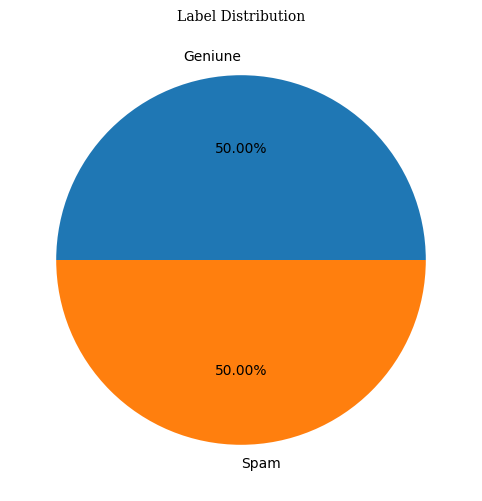

In [12]:
plt.figure(figsize=(10,6))
plt.pie(df['label'].value_counts(),autopct='%.2f%%',labels=['Geniune','Spam'])
plt.title('Label Distribution',fontsize=20,font='serif')

In [13]:
nltk.download('english')

[nltk_data] Error loading english: Package 'english' not found in
[nltk_data]     index


False

In [14]:
nltk.download('punkt_tab')
df['num_sen'] = df['subject'].apply(lambda x: len(nltk.sent_tokenize(x))) + df['mail_content'].apply(lambda x: len(nltk.sent_tokenize(x)))
df['num_word'] = df['subject'].apply(lambda x: len(nltk.word_tokenize(x))) + df['mail_content'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_char'] = df['subject'].str.len() + df['mail_content'].str.len()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [15]:
df

,subject,mail_content,label,num_sen,num_word,num_char
0,"Claim your $1,792,357 prize",We are pleased to inform you that your email a...,1,3,45,231
1,Important notice,Final notice: your subscription payment failed...,1,5,84,459
2,Chase account alert,This is a notification regarding an automatic ...,0,3,34,192
3,Immediate action required: security threat det...,"Dear Mei,\n\nOur security systems have detecte...",1,11,213,1153
4,Itinerary confirmed,"Good morning Ryan,\n\nThis confirms your upcom...",0,6,44,238
...,...,...,...,...,...,...
199995,Save $254 on your insurance,"Dear Angela,\n\nYou may be eligible for a lowe...",1,5,73,367
199996,FYI,"Hi Chidi,\n\nThanks for your feedback, we've p...",0,9,177,934
199997,Virus detected on your device,"Dear Nancy,\n\nOur security systems have detec...",1,6,82,497
199998,Redelivery fee required,We attempted to deliver your package (tracking...,1,3,39,223


In [16]:
df[['num_char','num_sen','num_word']].describe()

,num_char,num_sen,num_word
count,200000.000000,200000.000000,200000.000000
mean,539.158815,6.669640,102.785845
std,310.499536,2.550152,59.321690
min,54.000000,2.000000,10.000000
25%,254.000000,5.000000,48.000000
50%,455.000000,6.000000,87.000000
75%,880.000000,9.000000,170.000000
max,1350.000000,14.000000,246.000000


In [17]:
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def transform_data(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    text = [word for word in text if word.isalnum()]
    text = [word for word in text if word  not in stop_words]
    text = [ps.stem(word) for word in text]

    return " ".join(text)

In [19]:

# Apply transform_text function to both 'title' and 'text' columns and combine the results
df['transformed_text'] = df.apply(lambda row: transform_data(row['subject']) +' '+ transform_data(row['mail_content']), axis=1)


In [20]:
df.transformed_text.sample(10)

24732     special offer expir soon hello valu subscrib u...
106530    claim prize pleas inform email address select ...
9260      subscript renew notic hiya pamela note subscri...
172497    subscript renew receipt dear member youtub pre...
20827     cours announc good afternoon registr next seme...
141867    agenda tuesday call stephen like set time go s...
194627    bright horizon nonprofit newslett latest edit ...
58980     10 sitewid weekend hey limit time enjoy 10 sit...
15503     request patricia mark urgent sinc deadlin move...
161806    regard recent inquiri hello andrew thank reach...
Name: transformed_text, dtype: str

In [21]:
# from wordcloud import WordCloud
# wc = WordCloud(width=600, height=600, min_font_size=10, background_color='white')


In [22]:
# truemail=wc.generate(df[df['label']==0]['transformed_text'].str.cat(sep=" "))
# plt.figure(figsize=(15,6))
# plt.imshow(truemail)

In [23]:
# spammail=wc.generate(df[df['label']==1]['transformed_text'].str.cat(sep=" "))
# plt.figure(figsize=(15,6))
# plt.imshow(spammail)

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfid = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1,2),
    max_features=3000
)

In [25]:
df_clean = df.drop_duplicates(
    subset='transformed_text'
).reset_index(drop=True)

In [26]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_clean['transformed_text'],
    df_clean['label'].astype(int),
    test_size=0.2,
    random_state=42,
    stratify=df_clean['label']
)

X_train = tfid.fit_transform(X_train_text)
X_test = tfid.transform(X_test_text)

In [27]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,classification_report,recall_score,f1_score

For test
Accuracy : 0.986535972906743
Precision: 1.0
Recall   : 0.97102050491881
F1 Score : 0.9852972127845094


For train
Accuracy : 0.9854824054188006
Precision: 1.0
Recall   : 0.9687527780247133
F1 Score : 0.9841284175829138

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19445
           1       1.00      0.97      0.99     16874

    accuracy                           0.99     36319
   macro avg       0.99      0.99      0.99     36319
weighted avg       0.99      0.99      0.99     36319



Text(0.5, 1.0, 'Confusion Matrix')

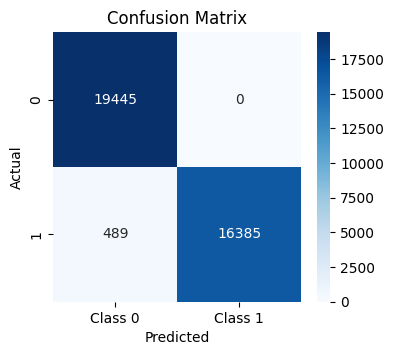

In [28]:
model = MultinomialNB()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

y_pred_train = model.predict(X_train)

print('For test')
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


print('\n\nFor train')
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train))
print("Recall   :", recall_score(y_train, y_pred_train))
print("F1 Score :", f1_score(y_train, y_pred_train))


print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3.5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap="Blues", xticklabels=["Class 0", "Class 1"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')

In [29]:
predictedtext = transform_data( """
Hi Kunj,

Your amazon order has been sucessfully dispatched from our warehouse.
""")
input_tfidf = tfid.transform([predictedtext])
user_prediction = model.predict(input_tfidf)
print("Predicted Label: ", user_prediction)

Predicted Label:  [0]


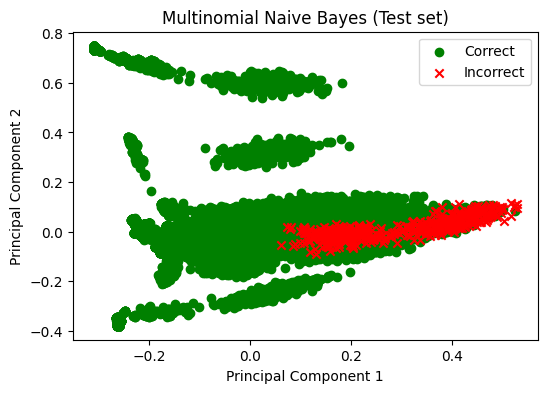

In [30]:
from sklearn.decomposition import PCA

# Get the predicted labels
y_pred = model.predict(X_test)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

# Create a boolean mask for correctly and incorrectly predicted points
correctly_predicted = (y_pred == y_test)
incorrectly_predicted = (y_pred != y_test)

plt.figure(figsize=(6, 4))

# Plotting the data points
plt.scatter(X_pca[correctly_predicted, 0], X_pca[correctly_predicted, 1], label='Correct', c='green', marker='o')
plt.scatter(X_pca[incorrectly_predicted, 0], X_pca[incorrectly_predicted, 1], label='Incorrect', c='red', marker='x')

plt.title('Multinomial Naive Bayes (Test set)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.savefig("mnb_test.png")
plt.show()

In [31]:
from sklearn.ensemble import RandomForestClassifier


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    max_features='sqrt',
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)


For test
Accuracy : 0.9996420606294226
Precision: 0.999881411206641
Recall   : 0.999348109517601
F1 Score : 0.999614689232046


For train
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19445
           1       1.00      1.00      1.00     16874

    accuracy                           1.00     36319
   macro avg       1.00      1.00      1.00     36319
weighted avg       1.00      1.00      1.00     36319



Text(0.5, 1.0, 'Confusion Matrix')

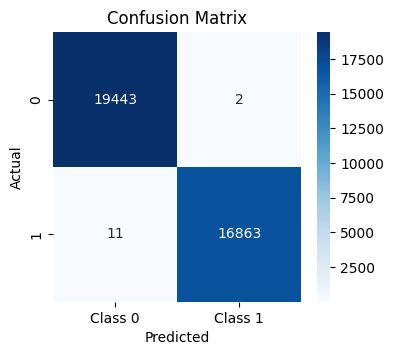

In [33]:
model = rf
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

y_pred_train = model.predict(X_train)

print('For test')
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


print('\n\nFor train')
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train))
print("Recall   :", recall_score(y_train, y_pred_train))
print("F1 Score :", f1_score(y_train, y_pred_train))


print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3.5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap="Blues", xticklabels=["Class 0", "Class 1"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')

In [34]:
import pickle

# Save the Multinomial Naive Bayes model
with open('multinomial_naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Also save the TfidfVectorizer for preprocessing
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfid, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


# Deep Learning with use of LSTM & GRU

In [35]:
# !pip install tensorflow

In [36]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping

In [37]:
# Ensure the cleaning function exists before using it
if 'clean_data' not in globals():
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))

    def clean_data(text):
        
        text = text.lower()
        text = nltk.word_tokenize(text)
        text = [word for word in text if word.isalnum() and word not in stop_words]
        text = [ps.stem(word) for word in text]
        return " ".join(text)

# Apply the cleaning function to the transformed text column
df_clean['transformed_text'] = df_clean['transformed_text'].apply(clean_data)

### Resplit the data for deep learning

In [38]:
xTrain, xTest, yTrain, yTest = train_test_split(
    df_clean['transformed_text'],
    df_clean['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_clean['label']
)

In [39]:
xTrain.shape, xTest.shape

((145272,), (36319,))

In [40]:
max_len = 150

trunc_type = 'post'
padding_type = 'post'
embedding_dim=128
oov_tok = '<OOV>'

vocab_size = 10000  # determine this from your actual vocabulary

### Tokenization

In [41]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(xTrain)
word_index = tokenizer.word_index
print(len(word_index))



30562


### Train Sequences & Padding

In [42]:
train_sequences = tokenizer.texts_to_sequences(xTrain)
test_sequences = tokenizer.texts_to_sequences(xTest)

### Test Sequence & Padding

In [43]:
padded_train = pad_sequences(
    train_sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

padded_test = pad_sequences(
    test_sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)


In [44]:
print('Shape of training tensor: ', padded_train.shape)
print('Shape of testing tensor: ', padded_test.shape)

Shape of training tensor:  (145272, 150)
Shape of testing tensor:  (36319, 150)


### Define the model architecture & tarin the model

In [45]:
vocab_size = 10000

embedding_dim = 64

drop_value = 0.3

n_dense = 32

In [46]:
# from tensorflow.keras.layers import GlobalAveragePooling1D

# model = Sequential()
# model.add(Embedding(vocab_size, embedding_dim, input_length=max_len))
# model.add(LSTM(64))
# model.add(Dropout(drop_value))
# model.add(Dense(n_dense, activation='relu'))
# model.add(Dropout(drop_value))
# model.add(Dense(1, activation='sigmoid'))

In [47]:
from tensorflow.keras.layers import GRU

model = Sequential()
model.add(Embedding(vocab_size, 128, input_length=max_len))
model.add(GRU(128))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

In [48]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

num_epochs = 30
early_stop = EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(padded_train,
                    yTrain.astype('int'),
                    epochs=num_epochs,
                    batch_size=64,
                    validation_data=(padded_test, yTest.astype('int')),
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/20
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 222s 97ms/step - accuracy: 0.5345 - loss: 0.6910 - val_accuracy: 0.5354 - val_loss: 0.6908
Epoch 2/20
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 284s 125ms/step - accuracy: 0.5354 - loss: 0.6908 - val_accuracy: 0.5354 - val_loss: 0.6907
Epoch 3/20
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 299s 132ms/step - accuracy: 0.5353 - loss: 0.6907 - val_accuracy: 0.5354 - val_loss: 0.6906
Epoch 4/20
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 296s 130ms/step - accuracy: 0.5354 - loss: 0.6907 - val_accuracy: 0.5354 - val_loss: 0.6907
Epoch 5/20
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 295s 130ms/step - accuracy: 0.5354 - loss: 0.6907 - val_accuracy: 0.5354 - val_loss: 0.6907
Epoch 6/20
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 299s 132ms/step - accuracy: 0.5354 - loss: 0.6907 - val_accuracy: 0.5354 - val_loss: 0.6907


In [50]:
test_loss, test_accuracy = model.evaluate(
    padded_test,
    yTest.astype('int'),
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1135/1135 ━━━━━━━━━━━━━━━━━━━━ 34s 30ms/step - accuracy: 0.5354 - loss: 0.6907
Test Loss: 0.6906521916389465
Test Accuracy: 0.5353946685791016


In [51]:
model.evaluate(padded_test, yTest.astype('int'))

1135/1135 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.5354 - loss: 0.6907


[0.6906521916389465, 0.5353946685791016]

In [52]:
y_pred_prob = model.predict(padded_test)

print(y_pred_prob[:10])

y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

1135/1135 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step
[[0.46218616]
 [0.46218616]
 [0.46218616]
 [0.46218616]
 [0.46218616]
 [0.46218616]
 [0.46218616]
 [0.46218616]
 [0.46218616]
 [0.46218616]]


In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_lstm = accuracy_score(yTest.astype('int'), y_pred)

precision_lstm = precision_score(yTest.astype('int'), y_pred)

recall_lstm = recall_score(yTest.astype('int'), y_pred)

f1_lstm = f1_score(yTest.astype('int'), y_pred)

print("Accuracy :", accuracy_lstm)
print("Precision:", precision_lstm)
print("Recall   :", recall_lstm)
print("F1 Score :", f1_lstm)

Accuracy : 0.5353946969905559
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [54]:
con_matrix = confusion_matrix(yTest.astype('int'),y_pred)

In [55]:
con_matrix

array([[19445,     0],
       [16874,     0]])